# Customer Service Performance & Satisfaction Analytics


## Objectives

1. To identify meaningful patterns, trends, and insights in customer service tickets through Exploratory Data Analysis (EDA).

2. To clean, transform, and preprocess customer service ticket data to ensure reliable and accurate analysis.

3. To analyze customer service performance based on ticket status, priority, issue category, service channel, city

4. To evaluate customer satisfaction using CSAT scores and identify factors associated with higher and lower customer satisfaction.

5. To create meaningful visualizations that clearly communicate customer service trends and performance patterns.

6. To provide actionable business insights and recommendations that can help improve customer service efficiency and customer satisfaction.

## Outcome

The project provide insights into customer service performance,
ticket trends, resolution efficiency, customer satisfaction, and refund
patterns.

The final analysis  identify major customer service issues, high-volume
support channels, resolution patterns, and areas requiring improvement.

The findings  be presented through Python-based analysis and an interactive
Power BI dashboard to support data-driven business decision-making.

## Domain

Customer Service / Customer Experience Analytics

## Dataset Information

**Dataset:** Saudi Customer Service Support Tickets 2024–2026

**Source:** [Prime Levels – Saudi Customer Service Tickets Dataset 2024–2026](https://prime-levels.com/data-hub/saudi-customer-service-tickets-2024-2026)

**Dataset Size:** 1,998 rows × 15 columns

**Timeline:** 2024–2026

**Format:** CSV

**Geographical Coverage:** Saudi Arabia

### Dataset Column / Features Description

- ticket_id – Unique identifier for each customer service ticket.
- customer_id – Unique identifier for the customer.
- customer_name – Name of the customer.
- channel – Customer service channel used to raise the ticket.
- issue_category – Category of the customer issue.
- priority – Priority assigned to the ticket.
- agent – Customer service agent handling the ticket.
- city – Customer location/city.
- created_date – Date when the ticket was created.
- resolved_date – Date when the ticket was resolved.
- first_response_time – Time taken by the agent to provide the first response.
- resolution_time – Time taken to resolve the ticket.
- ticket_status – Current status of the ticket.
- csat_score – Customer satisfaction score.
- refund_amount – Refund amount associated with the ticket.

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

### Business Problem and Expected Outcome

The objective is to analyze customer service tickets to understand support
volume, service efficiency, customer satisfaction, and refund patterns.

The analysis will help identify common customer issues, evaluate service
channels and agent performance, understand response and resolution times,
and identify areas where customer service operations can be improved.

### Dataset Selection

The Saudi Customer Service Support Tickets dataset is selected for this
project. It contains 1,998 customer service tickets with 15 features,
covering the period 2024–2026.

The dataset includes customer information, ticket details, service channels,
issue categories, priorities, agents, cities, response and resolution times,
ticket status, customer satisfaction scores, and refund amounts.

### Source

[Prime Levels – Saudi Customer Service Tickets Dataset 2024–2026](https://prime-levels.com/data-hub/saudi-customer-service-tickets-2024-2026)

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

df = pd.read_csv("Customer-service-tickets-ksa.csv")

In [3]:
df.head()

,ticket_id,customer_id,customer_name,channel,issue_category,priority,agent_name,city,created_date,resolved_date,first_response_minutes,resolution_time_hours,ticket_status,csat_score,refund_amount_sar
0,TCK-000001,CUST-14562,Yousef Al-Anazi,Phone,General Inquiry,Medium,Turki Al-Subaie,Jeddah,07-06-2024,10-06-2024,222,88.4,Resolved,3,0.0
1,TCK-000002,CUST-10776,Dana Al-Otaibi,Live Chat,Billing,Low,Mohammed Al-Harbi,Mecca,22-11-2025,Not Resolved,459,0.0,Escalated,0,0.0
2,TCK-000003,CUST-67589,Bandar Al-Dossari,Branch,Technical Support,Medium,Sara Al-Dossari,Riyadh,21-03-2024,25-03-2024,177,103.3,Resolved,4,0.0
3,TCK-000004,CUST-84384,Nasser Al-Qahtani,Phone,Billing,Low,Abdullah Al-Zahrani,Dammam,03-03-2024,04-03-2024,522,30.7,Resolved,1,0.0
4,TCK-000005,CUST-28922,Yousef Al-Dossari,WhatsApp,General Inquiry,Medium,Noura Al-Shammari,Riyadh,31-07-2026,Not Resolved,138,0.0,Pending,0,0.0


In [4]:
df.shape

(1998, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ticket_id               1998 non-null   object 
 1   customer_id             1998 non-null   object 
 2   customer_name           1998 non-null   object 
 3   channel                 1938 non-null   object 
 4   issue_category          1938 non-null   object 
 5   priority                1998 non-null   object 
 6   agent_name              1998 non-null   object 
 7   city                    1938 non-null   object 
 8   created_date            1998 non-null   object 
 9   resolved_date           1998 non-null   object 
 10  first_response_minutes  1998 non-null   int64  
 11  resolution_time_hours   1998 non-null   float64
 12  ticket_status           1998 non-null   object 
 13  csat_score              1998 non-null   int64  
 14  refund_amount_sar       1998 non-null   

In [6]:
df.describe()

,first_response_minutes,resolution_time_hours,csat_score,refund_amount_sar
count,1998.000000,1998.000000,1998.000000,1998.000000
mean,185.873373,49.285936,2.692693,258.247668
std,180.591238,59.485198,2.001416,837.872279
min,2.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,0.000000
50%,125.000000,27.000000,3.000000,0.000000
75%,260.000000,80.650000,5.000000,0.000000
max,719.000000,240.000000,5.000000,4497.280000


In [7]:
df.describe(include="object")

,ticket_id,customer_id,customer_name,channel,issue_category,priority,agent_name,city,created_date,resolved_date,ticket_status
count,1998,1998,1998,1938,1938,1998,1998,1938,1998,1998,1998
unique,1998,1971,280,6,7,4,14,10,887,779,5
top,TCK-001998,CUST-98215,Abdullah Al-Shehri,Phone,Technical Support,Medium,Noura Al-Shammari,Riyadh,06-04-2024,Not Resolved,Resolved
freq,1,3,13,508,436,804,166,549,8,569,1021


In [8]:
df.isnull().sum()

,0
ticket_id,0
customer_id,0
customer_name,0
channel,60
issue_category,60
priority,0
agent_name,0
city,60
created_date,0
resolved_date,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Convert created_date,resolved_date to datetime

In [11]:
df['created_date'] = pd.to_datetime(df['created_date'],format='%d-%m-%Y')

In [12]:
df['resolved_date'] = pd.to_datetime(df['resolved_date'],format='%d-%m-%Y',errors='coerce')

In [13]:
df[['created_date', 'resolved_date']].dtypes

,0
created_date,datetime64[ns]
resolved_date,datetime64[ns]


In [14]:
print("Missing resolved dates after conversion:",df['resolved_date'].isnull().sum())

Missing resolved dates after conversion: 569


In [15]:
df[['created_date', 'resolved_date', 'ticket_status']].head(10)

,created_date,resolved_date,ticket_status
0,2024-06-07,2024-06-10,Resolved
1,2025-11-22,NaT,Escalated
2,2024-03-21,2024-03-25,Resolved
3,2024-03-03,2024-03-04,Resolved
4,2026-07-31,NaT,Pending
5,2026-02-13,2026-02-16,Resolved
6,2026-06-28,2026-07-06,Resolved
7,2026-02-18,2026-02-21,Resolved
8,2026-04-01,2026-04-01,Closed
9,2026-04-28,NaT,Open


In [16]:
# Display rows where any of the three columns is missing

missing_rows = df[df[['channel', 'issue_category', 'city']].isnull().any(axis=1)]
missing_rows.head(20)

,ticket_id,customer_id,customer_name,channel,issue_category,priority,agent_name,city,created_date,resolved_date,first_response_minutes,resolution_time_hours,ticket_status,csat_score,refund_amount_sar
10,TCK-000011,CUST-26842,Dana Al-Dossari,Branch,NaN,Low,Noura Al-Shammari,Jeddah,2024-07-04,NaT,34,0.0,Pending,0,0.00
27,TCK-000028,CUST-23253,Turki Al-Otaibi,Phone,NaN,Low,Faisal Al-Shehri,Jeddah,2024-04-23,NaT,58,0.0,Pending,0,0.00
35,TCK-000036,CUST-54619,Mohammed Al-Anazi,Live Chat,NaN,High,Khalid Al-Ghamdi,Tabuk,2025-06-16,2025-06-16,34,3.1,Resolved,5,0.00
43,TCK-000044,CUST-28960,Sultan Al-Zahrani,Live Chat,NaN,Low,Fahad Al-Otaibi,Jeddah,2026-01-06,2026-01-08,245,69.3,Resolved,5,0.00
44,TCK-000045,CUST-33385,Abdullah Al-Zahrani,NaN,General Inquiry,Low,Huda Al-Anazi,Mecca,2026-04-08,2026-04-17,399,223.5,Resolved,3,0.00
45,TCK-000046,CUST-56118,Mohammed Al-Malki,Phone,Complaint,Medium,Sara Al-Dossari,NaN,2024-11-14,2024-11-16,23,58.4,Resolved,4,2895.58
60,TCK-000061,CUST-13568,Turki Al-Dossari,Phone,General Inquiry,Low,Reem Al-Mutairi,NaN,2025-12-07,2025-12-11,102,100.1,Resolved,3,0.00
62,TCK-000063,CUST-46339,Sara Al-Subaie,Phone,NaN,Critical,Abdullah Al-Zahrani,Riyadh,2026-02-20,NaT,8,0.0,Escalated,0,0.00
68,TCK-000069,CUST-56582,Abdullah Al-Rashidi,Email,Billing,Low,Yousef Al-Malki,NaN,2024-04-23,2024-04-29,412,157.7,Resolved,5,3240.71
81,TCK-000082,CUST-15591,Mohammed Al-Dossari,NaN,Billing,High,Khalid Al-Ghamdi,Jeddah,2024-10-17,2024-10-17,47,13.0,Closed,4,0.00


In [17]:
# Count missing values
df[['channel', 'issue_category', 'city']].isnull().sum()

,0
channel,60
issue_category,60
city,60


In [18]:
# Check combinations of missing values

df[df[['channel', 'issue_category', 'city']].isnull().any(axis=1)][['channel', 'issue_category', 'city']].isnull().value_counts()

channel  issue_category  city 
True     False           False    60
False    False           True     58
         True            False    58
                         True      2
Name: count, dtype: int64

In [19]:
# Fill missing categorical values with "Unknown"

categorical_columns = ['channel', 'issue_category', 'city']

for column in categorical_columns:
    df[column] = df[column].fillna('Unknown')

In [20]:
# Check unique values in categorical columns

categorical_columns = [
    'channel',
    'issue_category',
    'priority',
    'agent_name',
    'city',
    'ticket_status'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].unique())


--- channel ---
['Phone' 'Live Chat' 'Branch' 'WhatsApp' 'Email' 'Social Media' 'Unknown']

--- issue_category ---
['General Inquiry' 'Billing' 'Technical Support' 'Refund Request'
 'Unknown' 'Account Management' 'Delivery Issue' 'Complaint']

--- priority ---
['Medium' 'Low' 'High' 'Critical']

--- agent_name ---
['Turki Al-Subaie' 'Mohammed Al-Harbi' 'Sara Al-Dossari'
 'Abdullah Al-Zahrani' 'Noura Al-Shammari' 'Maha Al-Balawi'
 'Reem Al-Mutairi' 'Khalid Al-Ghamdi' 'Lama Al-Rashidi' 'Huda Al-Anazi'
 'Yousef Al-Malki' 'Fahad Al-Otaibi' 'Faisal Al-Shehri' 'Ahmed Al-Qahtani']

--- city ---
['Jeddah' 'Mecca' 'Riyadh' 'Dammam' 'Medina' 'Khobar' 'Hail' 'Buraidah'
 'Tabuk' 'Abha' 'Unknown']

--- ticket_status ---
['Resolved' 'Escalated' 'Pending' 'Closed' 'Open']


In [21]:
df[categorical_columns].isnull().sum()

,0
channel,0
issue_category,0
priority,0
agent_name,0
city,0
ticket_status,0


In [22]:
for column in categorical_columns:
    df[column] = df[column].str.strip()

In [23]:
# Check the complete dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ticket_id               1998 non-null   object        
 1   customer_id             1998 non-null   object        
 2   customer_name           1998 non-null   object        
 3   channel                 1998 non-null   object        
 4   issue_category          1998 non-null   object        
 5   priority                1998 non-null   object        
 6   agent_name              1998 non-null   object        
 7   city                    1998 non-null   object        
 8   created_date            1998 non-null   datetime64[ns]
 9   resolved_date           1429 non-null   datetime64[ns]
 10  first_response_minutes  1998 non-null   int64         
 11  resolution_time_hours   1998 non-null   float64       
 12  ticket_status           1998 non-null   object  

In [24]:
# Check missing values across the entire dataset

df.isnull().sum()

,0
ticket_id,0
customer_id,0
customer_name,0
channel,0
issue_category,0
priority,0
agent_name,0
city,0
created_date,0
resolved_date,569


In [25]:
# Check duplicate rows again after preprocessing

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Feature engineering

In [26]:
# Create resolution status
df['resolution_status'] = np.where(df['resolved_date'].notna(),'Resolved','Unresolved')

# Check the result
df['resolution_status'].value_counts()

,count
resolution_status,
Resolved,1429
Unresolved,569


In [27]:
# Calculate resolution time in days

df['resolution_days'] = (df['resolved_date'] - df['created_date']).dt.days
# Display the result
df[['created_date', 'resolved_date', 'resolution_days', 'resolution_status']].head(10)

,created_date,resolved_date,resolution_days,resolution_status
0,2024-06-07,2024-06-10,3.0,Resolved
1,2025-11-22,NaT,NaN,Unresolved
2,2024-03-21,2024-03-25,4.0,Resolved
3,2024-03-03,2024-03-04,1.0,Resolved
4,2026-07-31,NaT,NaN,Unresolved
5,2026-02-13,2026-02-16,3.0,Resolved
6,2026-06-28,2026-07-06,8.0,Resolved
7,2026-02-18,2026-02-21,3.0,Resolved
8,2026-04-01,2026-04-01,0.0,Resolved
9,2026-04-28,NaT,NaN,Unresolved


In [28]:
# Check for negative resolution days

(df['resolution_days'] < 0).sum()

np.int64(0)

In [29]:
# Create date-based derived columns

df['created_year'] = df['created_date'].dt.year

In [30]:
df['created_month'] = df['created_date'].dt.month_name()

In [31]:
df['created_month_year'] = df['created_date'].dt.to_period('M').astype(str)

In [32]:
# Display the result
df[['created_date', 'created_year', 'created_month', 'created_month_year']].head(10)

,created_date,created_year,created_month,created_month_year
0,2024-06-07,2024,June,2024-06
1,2025-11-22,2025,November,2025-11
2,2024-03-21,2024,March,2024-03
3,2024-03-03,2024,March,2024-03
4,2026-07-31,2026,July,2026-07
5,2026-02-13,2026,February,2026-02
6,2026-06-28,2026,June,2026-06
7,2026-02-18,2026,February,2026-02
8,2026-04-01,2026,April,2026-04
9,2026-04-28,2026,April,2026-04


In [33]:
# Create response time categories

df['response_category'] = pd.cut(
    df['first_response_minutes'],
    bins=[0, 30, 60, 180, float('inf')],
    labels=['Very Fast', 'Fast', 'Moderate', 'Slow'],
    include_lowest=True
)

# Check the categories
df['response_category'].value_counts()

,count
response_category,
Slow,792
Moderate,590
Very Fast,339
Fast,277


In [34]:
# Display first response time with its category

df[['first_response_minutes', 'response_category']].head(15)

,first_response_minutes,response_category
0,222,Slow
1,459,Slow
2,177,Moderate
3,522,Slow
4,138,Moderate
5,262,Slow
6,628,Slow
7,568,Slow
8,27,Very Fast
9,27,Very Fast


In [35]:
# Find the latest ticket creation date
analysis_date = df['created_date'].max()

print("Analysis date:", analysis_date)

Analysis date: 2026-10-31 00:00:00


In [36]:
# Calculate ticket age in days

df['ticket_age_days'] = np.where(
    df['resolution_status'] == 'Unresolved',
    (analysis_date - df['created_date']).dt.days,
    np.nan
)

# Display the result
df[['created_date', 'resolved_date', 'ticket_status',
    'resolution_status', 'ticket_age_days']].head(15)

,created_date,resolved_date,ticket_status,resolution_status,ticket_age_days
0,2024-06-07,2024-06-10,Resolved,Resolved,NaN
1,2025-11-22,NaT,Escalated,Unresolved,343.0
2,2024-03-21,2024-03-25,Resolved,Resolved,NaN
3,2024-03-03,2024-03-04,Resolved,Resolved,NaN
4,2026-07-31,NaT,Pending,Unresolved,92.0
5,2026-02-13,2026-02-16,Resolved,Resolved,NaN
6,2026-06-28,2026-07-06,Resolved,Resolved,NaN
7,2026-02-18,2026-02-21,Resolved,Resolved,NaN
8,2026-04-01,2026-04-01,Closed,Resolved,NaN
9,2026-04-28,NaT,Open,Unresolved,186.0


In [37]:
# Check all columns after preprocessing

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Total rows: 1998
Total columns: 22

Columns:
['ticket_id', 'customer_id', 'customer_name', 'channel', 'issue_category', 'priority', 'agent_name', 'city', 'created_date', 'resolved_date', 'first_response_minutes', 'resolution_time_hours', 'ticket_status', 'csat_score', 'refund_amount_sar', 'resolution_status', 'resolution_days', 'created_year', 'created_month', 'created_month_year', 'response_category', 'ticket_age_days']


In [38]:
# Check data types

df.dtypes

,0
ticket_id,object
customer_id,object
customer_name,object
channel,object
issue_category,object
priority,object
agent_name,object
city,object
created_date,datetime64[ns]
resolved_date,datetime64[ns]


In [39]:
# Final missing-value check

df.isnull().sum()

,0
ticket_id,0
customer_id,0
customer_name,0
channel,0
issue_category,0
priority,0
agent_name,0
city,0
created_date,0
resolved_date,569


In [40]:
# Check minimum and maximum values of numerical columns

numerical_columns = [
    'first_response_minutes',
    'resolution_time_hours',
    'csat_score',
    'refund_amount_sar',
    'resolution_days',
    'ticket_age_days'
]

df[numerical_columns].agg(['min', 'max'])

,first_response_minutes,resolution_time_hours,csat_score,refund_amount_sar,resolution_days,ticket_age_days
min,2,0.0,0,0.00,0.0,0.0
max,719,240.0,5,4497.28,10.0,1034.0


In [41]:
# Check for negative values

print("Negative first response times:",
      (df['first_response_minutes'] < 0).sum())

print("Negative resolution times:",
      (df['resolution_time_hours'] < 0).sum())

print("Negative resolution days:",
      (df['resolution_days'] < 0).sum())

print("Negative refund amounts:",
      (df['refund_amount_sar'] < 0).sum())

print("Negative ticket ages:",
      (df['ticket_age_days'] < 0).sum())

Negative first response times: 0
Negative resolution times: 0
Negative resolution days: 0
Negative refund amounts: 0
Negative ticket ages: 0


In [42]:
# Final shape of the preprocessed dataset

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])

print("\nFinal columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Final number of rows: 1998
Final number of columns: 22

Final columns:
1. ticket_id
2. customer_id
3. customer_name
4. channel
5. issue_category
6. priority
7. agent_name
8. city
9. created_date
10. resolved_date
11. first_response_minutes
12. resolution_time_hours
13. ticket_status
14. csat_score
15. refund_amount_sar
16. resolution_status
17. resolution_days
18. created_year
19. created_month
20. created_month_year
21. response_category
22. ticket_age_days


In [43]:
# Preview the cleaned dataset

df.head()

,ticket_id,customer_id,customer_name,channel,issue_category,priority,agent_name,city,created_date,resolved_date,...,ticket_status,csat_score,refund_amount_sar,resolution_status,resolution_days,created_year,created_month,created_month_year,response_category,ticket_age_days
0,TCK-000001,CUST-14562,Yousef Al-Anazi,Phone,General Inquiry,Medium,Turki Al-Subaie,Jeddah,2024-06-07,2024-06-10,...,Resolved,3,0.0,Resolved,3.0,2024,June,2024-06,Slow,NaN
1,TCK-000002,CUST-10776,Dana Al-Otaibi,Live Chat,Billing,Low,Mohammed Al-Harbi,Mecca,2025-11-22,NaT,...,Escalated,0,0.0,Unresolved,NaN,2025,November,2025-11,Slow,343.0
2,TCK-000003,CUST-67589,Bandar Al-Dossari,Branch,Technical Support,Medium,Sara Al-Dossari,Riyadh,2024-03-21,2024-03-25,...,Resolved,4,0.0,Resolved,4.0,2024,March,2024-03,Moderate,NaN
3,TCK-000004,CUST-84384,Nasser Al-Qahtani,Phone,Billing,Low,Abdullah Al-Zahrani,Dammam,2024-03-03,2024-03-04,...,Resolved,1,0.0,Resolved,1.0,2024,March,2024-03,Slow,NaN
4,TCK-000005,CUST-28922,Yousef Al-Dossari,WhatsApp,General Inquiry,Medium,Noura Al-Shammari,Riyadh,2026-07-31,NaT,...,Pending,0,0.0,Unresolved,NaN,2026,July,2026-07,Moderate,92.0


## Outlier summary

In [44]:
outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ][column].dropna()

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,first_response_minutes,48.0,260.00,212.00,-270.000,578.000,128
1,resolution_time_hours,0.0,80.65,80.65,-120.975,201.625,70
2,csat_score,0.0,5.00,5.00,-7.500,12.500,0
3,refund_amount_sar,0.0,0.00,0.00,0.000,0.000,228
4,resolution_days,0.0,4.00,4.00,-6.000,10.000,0
5,ticket_age_days,261.0,777.00,516.00,-513.000,1551.000,0


In [45]:
# Calculate IQR boundaries,first_response
Q1 = df['first_response_minutes'].quantile(0.25)
Q3 = df['first_response_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Get the outlier records
response_outliers = df[
    (df['first_response_minutes'] < lower_bound) |
    (df['first_response_minutes'] > upper_bound)
]

# Display the important columns
response_outliers[
    [
        'ticket_id',
        'first_response_minutes',
        'priority',
        'issue_category',
        'channel',
        'ticket_status',
        'csat_score'
    ]
].sort_values(
    'first_response_minutes',
    ascending=False
).head(20)

,ticket_id,first_response_minutes,priority,issue_category,channel,ticket_status,csat_score
612,TCK-000613,719,Low,Technical Support,Phone,Resolved,2
515,TCK-000516,719,Low,General Inquiry,Phone,Resolved,4
1384,TCK-001385,719,Low,General Inquiry,Phone,Resolved,4
1022,TCK-001023,719,Low,Refund Request,Live Chat,Open,0
1869,TCK-001870,719,Low,Billing,Email,Closed,5
1862,TCK-001863,717,Low,Account Management,Unknown,Resolved,5
655,TCK-000656,715,Low,Unknown,WhatsApp,Resolved,4
1682,TCK-001683,715,Low,Billing,WhatsApp,Resolved,5
1089,TCK-001090,714,Low,Billing,Email,Resolved,1
295,TCK-000296,714,Low,Refund Request,Phone,Resolved,3


In [46]:
#resolution time hours
Q1 = df['resolution_time_hours'].quantile(0.25)
Q3 = df['resolution_time_hours'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

resolution_outliers = df[
    (df['resolution_time_hours'] < lower_bound) |
    (df['resolution_time_hours'] > upper_bound)
]

resolution_outliers[
    [
        'ticket_id',
        'resolution_time_hours',
        'priority',
        'issue_category',
        'channel',
        'ticket_status',
        'csat_score'
    ]
].sort_values(
    'resolution_time_hours',
    ascending=False
).head(20)

,ticket_id,resolution_time_hours,priority,issue_category,channel,ticket_status,csat_score
1233,TCK-001234,240.0,Low,Delivery Issue,Phone,Resolved,4
94,TCK-000095,239.9,Low,General Inquiry,Live Chat,Resolved,4
1664,TCK-001665,238.9,Low,Billing,Social Media,Closed,1
1508,TCK-001509,238.1,Low,Billing,Live Chat,Resolved,5
1485,TCK-001486,237.4,Low,Complaint,WhatsApp,Closed,5
810,TCK-000811,236.6,Low,General Inquiry,Email,Resolved,4
1474,TCK-001475,235.6,Low,Complaint,Unknown,Closed,5
196,TCK-000197,235.5,Low,Billing,Email,Closed,5
804,TCK-000805,235.3,Low,Account Management,Phone,Closed,5
635,TCK-000636,234.6,Low,Unknown,Email,Closed,5


In [47]:
# Check the distribution of refund amounts
print(df['refund_amount_sar'].describe())

count    1998.000000
mean      258.247668
std       837.872279
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4497.280000
Name: refund_amount_sar, dtype: float64


In [48]:
# Count zero and positive refund amounts
print("Zero refund amounts:", (df['refund_amount_sar'] == 0).sum())
print("Positive refund amounts:", (df['refund_amount_sar'] > 0).sum())

Zero refund amounts: 1770
Positive refund amounts: 228


In [49]:
# Show the highest refund amounts
df[['ticket_id', 'refund_amount_sar', 'issue_category',
    'priority', 'channel', 'ticket_status', 'csat_score']] \
    .sort_values('refund_amount_sar', ascending=False) \
    .head(20)


,ticket_id,refund_amount_sar,issue_category,priority,channel,ticket_status,csat_score
1311,TCK-001312,4497.28,Delivery Issue,Medium,Phone,Closed,3
1953,TCK-001954,4486.19,Billing,Medium,Branch,Resolved,1
1146,TCK-001147,4480.91,Complaint,High,Live Chat,Resolved,3
1515,TCK-001516,4460.83,Billing,High,Phone,Resolved,4
332,TCK-000333,4457.60,Billing,Critical,Branch,Resolved,4
1002,TCK-001003,4434.76,Complaint,Low,Email,Closed,5
1696,TCK-001697,4432.12,Refund Request,Critical,Email,Resolved,3
1937,TCK-001938,4412.38,Billing,Low,Email,Closed,2
1279,TCK-001280,4375.80,Billing,Medium,Email,Resolved,5
954,TCK-000955,4354.60,Complaint,Low,Phone,Resolved,4


## Skewness Distribution Analysis


In [50]:
numerical_columns = [
    'first_response_minutes',
    'resolution_time_hours',
    'csat_score',
    'refund_amount_sar',
    'resolution_days',
    'ticket_age_days'
]

skewness = df[numerical_columns].skew()

print(skewness)

first_response_minutes    1.296285
resolution_time_hours     1.364375
csat_score               -0.269932
refund_amount_sar         3.433913
resolution_days           1.102910
ticket_age_days          -0.017688
dtype: float64


### Skewness Analysis

Skewness was calculated for the numerical variables to understand the distribution of the data.

The analysis showed that `first_response_minutes`, `resolution_time_hours`, `refund_amount_sar`, and `resolution_days` are positively skewed, while `csat_score` and `ticket_age_days` are approximately symmetric.

The positive skewness is mainly caused by a smaller number of tickets with relatively high response times, resolution times, resolution durations, and refund amounts. In particular, `refund_amount_sar` is highly right-skewed because most tickets have no refund while a smaller number have positive refund amounts.

Since the identified extreme values were reviewed and considered valid business observations, no values were removed. The original variables were retained without transformation so that their business meaning remains clear and interpretable during EDA and Power BI analysis.

### Stage 3-Statistical analysis & Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

In [51]:
# Statistical summary of numerical variables

statistical_summary = df[numerical_columns].describe().T
statistical_summary

,count,mean,std,min,25%,50%,75%,max
first_response_minutes,1998.0,185.873373,180.591238,2.0,48.0,125.0,260.00,719.00
resolution_time_hours,1998.0,49.285936,59.485198,0.0,0.0,27.0,80.65,240.00
csat_score,1998.0,2.692693,2.001416,0.0,0.0,3.0,5.00,5.00
refund_amount_sar,1998.0,258.247668,837.872279,0.0,0.0,0.0,0.00,4497.28
resolution_days,1429.0,2.388383,2.477553,0.0,0.0,2.0,4.00,10.00
ticket_age_days,569.0,521.493849,298.252706,0.0,261.0,511.0,777.00,1034.00


In [52]:
priority_analysis = df.groupby('priority').agg(
    ticket_count=('ticket_id', 'count'),
    avg_first_response_minutes=('first_response_minutes', 'mean'),
    avg_resolution_time_hours=('resolution_time_hours', 'mean'),
    avg_csat_score=('csat_score', 'mean')
).round(2)

priority_analysis

,ticket_count,avg_first_response_minutes,avg_resolution_time_hours,avg_csat_score
priority,,,,
Critical,165,14.82,4.75,2.68
High,437,47.14,17.56,2.76
Low,592,373.60,90.22,2.74
Medium,804,158.16,45.53,2.62


In [53]:
#Statistical Analysis by Issue Category

issue_analysis = df.groupby('issue_category').agg(
    ticket_count=('ticket_id', 'count'),
    avg_first_response_minutes=('first_response_minutes', 'mean'),
    avg_resolution_time_hours=('resolution_time_hours', 'mean'),
    avg_csat_score=('csat_score', 'mean')
).round(2)

issue_analysis

,ticket_count,avg_first_response_minutes,avg_resolution_time_hours,avg_csat_score
issue_category,,,,
Account Management,278,186.08,47.66,2.63
Billing,421,189.82,54.42,2.94
Complaint,215,190.40,49.22,2.66
Delivery Issue,133,188.59,52.95,2.59
General Inquiry,314,169.18,42.38,2.65
Refund Request,141,197.01,43.31,2.57
Technical Support,436,190.90,51.40,2.63
Unknown,60,159.63,47.79,2.62


In [54]:
#Channel-wise Performance

channel_analysis = df.groupby('channel').agg(
    ticket_count=('ticket_id', 'count'),
    avg_first_response_minutes=('first_response_minutes', 'mean'),
    avg_resolution_time_hours=('resolution_time_hours', 'mean'),
    avg_csat_score=('csat_score', 'mean')
).round(2)

channel_analysis

,ticket_count,avg_first_response_minutes,avg_resolution_time_hours,avg_csat_score
channel,,,,
Branch,158,186.69,58.66,2.86
Email,397,186.51,48.78,2.84
Live Chat,434,171.08,45.42,2.67
Phone,508,185.68,47.66,2.47
Social Media,147,206.97,52.94,2.82
Unknown,60,221.43,58.02,2.60
WhatsApp,294,188.94,49.84,2.78


## Univariate Analysis

In [55]:
# Ticket Status Distribution
#compare the number of tickets in each status

ticket_status_counts = df['ticket_status'].value_counts()

ticket_status_counts

,count
ticket_status,
Resolved,1021
Closed,408
Pending,247
Open,201
Escalated,121


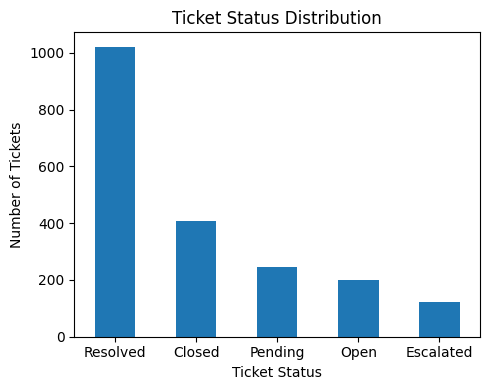

In [56]:
# Ticket Status Distribution - Bar Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
ticket_status_counts.plot(kind='bar')
plt.title('Ticket Status Distribution')
plt.xlabel('Ticket Status')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows the distribution of tickets across different ticket statuses.

- Resolved tickets have the highest count with 1,021 tickets.
- Closed tickets are the second highest with 408 tickets.
- Pending and Open tickets have 247 and 201 tickets respectively.
- Escalated tickets have the lowest count with 121 tickets.

Overall, the dataset contains more resolved and closed tickets than pending, open, or escalated tickets.

In [57]:
#Issue Category Distribution

issue_category_counts = df['issue_category'].value_counts()
issue_category_counts

,count
issue_category,
Technical Support,436
Billing,421
General Inquiry,314
Account Management,278
Complaint,215
Refund Request,141
Delivery Issue,133
Unknown,60


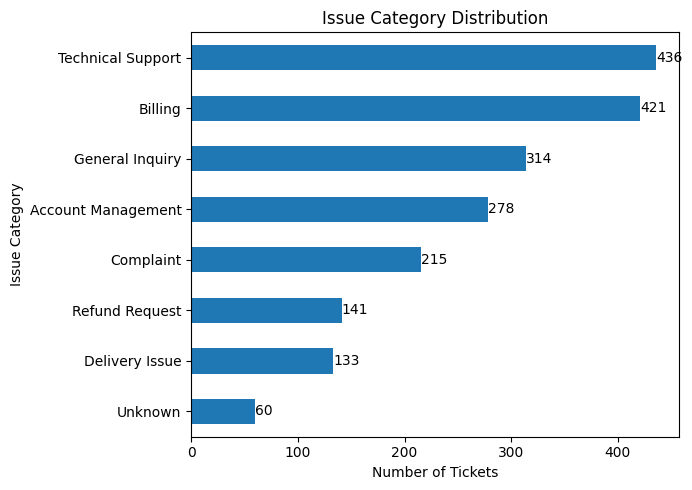

In [58]:
# Issue Category Distribution - Bar Chart

plt.figure(figsize=(7, 5))
ax = issue_category_counts.sort_values().plot(kind='barh')
plt.title('Issue Category Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Issue Category')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows the distribution of tickets across different issue categories.

- Technical Support has the highest number of tickets with 436 records.
- Billing follows closely with 421 tickets.
- General Inquiry accounts for 314 tickets, followed by Account Management with 278 tickets.
- Complaint has 215 tickets.
- Refund Request and Delivery Issue have 141 and 133 tickets respectively.
- Unknown has the lowest count with 60 tickets, representing records where the original issue category was missing.

Overall, Technical Support and Billing represent the largest issue categories in the dataset.

In [59]:
# Priority Distribution
#to understand the workload distribution by priority

priority_counts = df['priority'].value_counts()
priority_counts

,count
priority,
Medium,804
Low,592
High,437
Critical,165


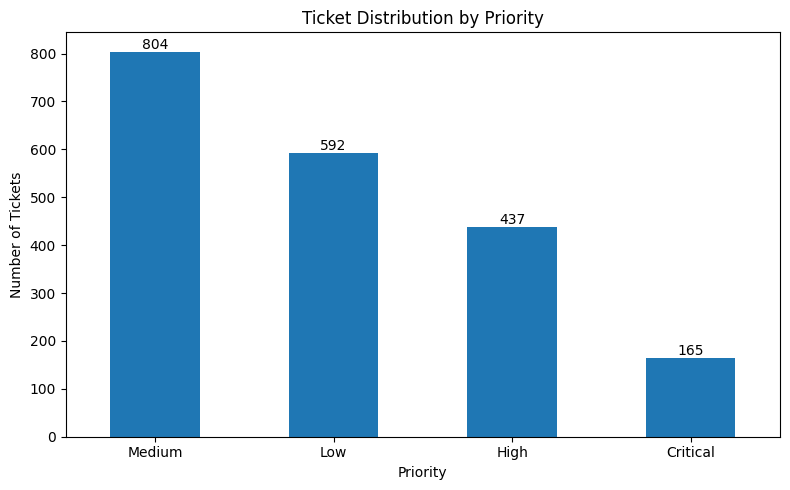

In [60]:
# Priority Distribution - Bar Chart

plt.figure(figsize=(8, 5))
ax = priority_counts.plot(kind='bar')
plt.title('Ticket Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows the distribution of tickets across different priority levels.

- Medium-priority tickets have the highest count with 804 tickets.
- Low-priority tickets account for 592 tickets.
- High-priority tickets account for 437 tickets.
- Critical-priority tickets have the lowest count with 165 tickets.

Overall, Medium and Low priority tickets make up the larger share of the tickets in the dataset, while Critical tickets represent the smallest priority group.

In [61]:
# Channel Distribution
#to understand which channels generate the highest customer-service workload

channel_counts = df['channel'].value_counts()
channel_counts

,count
channel,
Phone,508
Live Chat,434
Email,397
WhatsApp,294
Branch,158
Social Media,147
Unknown,60


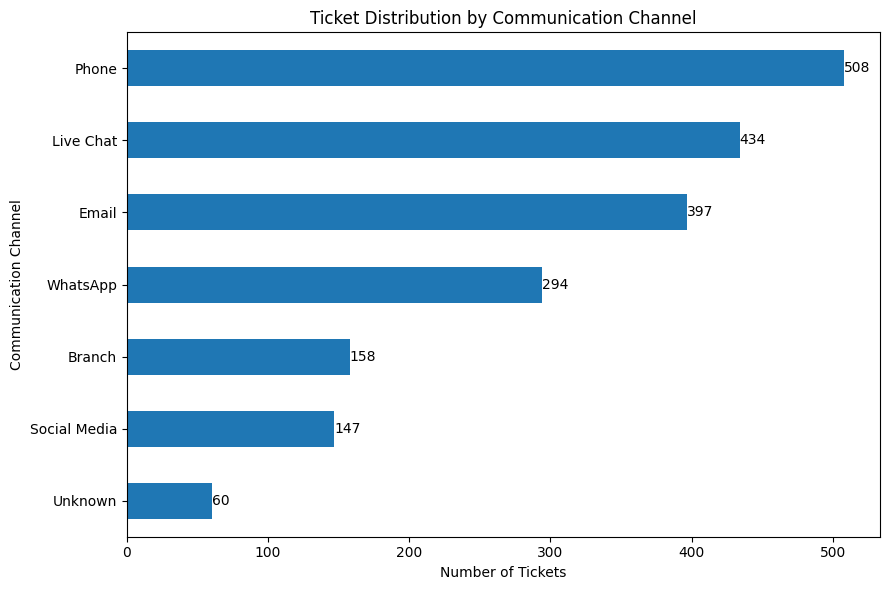

In [62]:
# Channel Distribution - Bar Chart

plt.figure(figsize=(9, 6))
ax = channel_counts.sort_values().plot(kind='barh')
plt.title('Ticket Distribution by Communication Channel')
plt.xlabel('Number of Tickets')
plt.ylabel('Communication Channel')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows the distribution of tickets across different communication channels.

- Phone has the highest number of tickets with 508 records.
- Live Chat follows with 434 tickets.
- Email accounts for 397 tickets, followed by WhatsApp with 294 tickets.
- Branch and Social Media have 158 and 147 tickets respectively.
- Unknown has the lowest count with 60 tickets, representing records where the original channel information was missing.

Overall, Phone, Live Chat, and Email are the most frequently used communication channels in the dataset.

In [63]:
# CSAT Score Distribution
#to understand how customer satisfaction responses are spread across the available scores

csat_counts = df['csat_score'].value_counts().sort_index()
csat_counts

,count
csat_score,
0,569
1,103
2,155
3,240
4,408
5,523


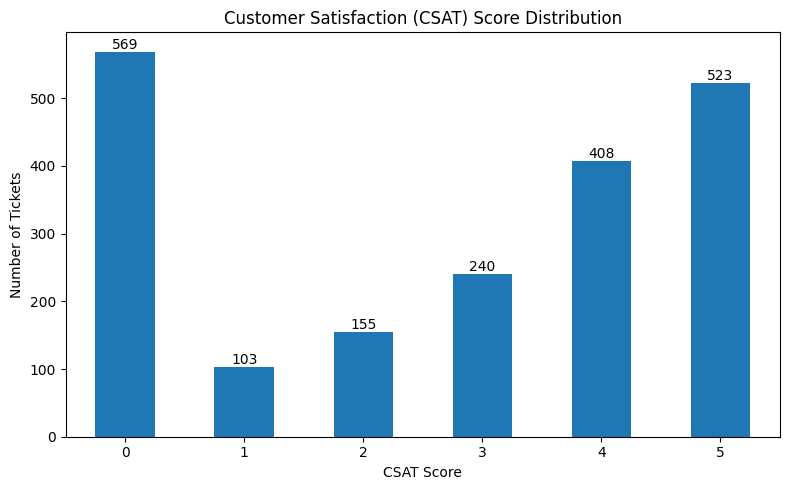

In [64]:
# CSAT Score Distribution - Bar Chart

plt.figure(figsize=(8, 5))
ax = csat_counts.plot(kind='bar')
plt.title('Customer Satisfaction (CSAT) Score Distribution')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows the distribution of customer satisfaction (CSAT) scores from 0 to 5.

- A CSAT score of 0 has the highest frequency with 569 tickets.
- A score of 5 is the second most frequent with 523 tickets.
- Scores of 4 and 3 account for 408 and 240 tickets respectively.
- Lower frequencies are observed for scores of 1 and 2, with 103 and 155 tickets respectively.

Overall, the CSAT distribution is spread across both low and high satisfaction scores, with scores of 0 and 5 occurring most frequently. This indicates that customer satisfaction is not concentrated around a single score in this dataset.

### Bivariate analysis

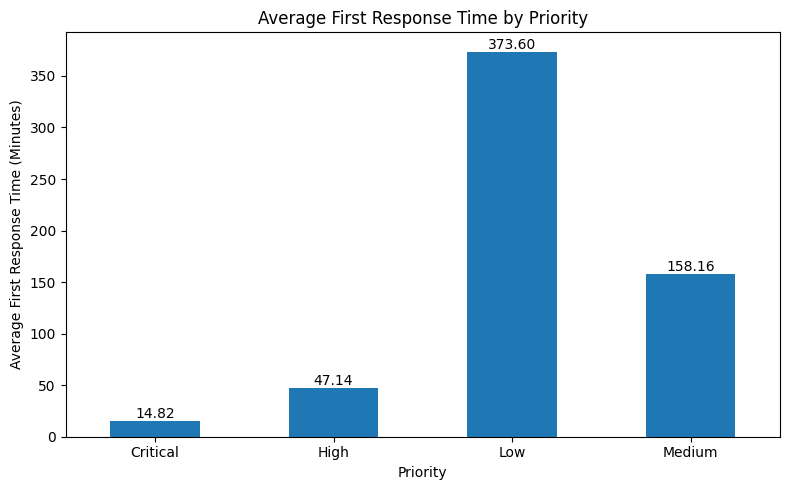

In [65]:
# Average First Response Time by Priority
#to compare the average first response time across different priority levels

plt.figure(figsize=(8, 5))
ax = priority_analysis['avg_first_response_minutes'].plot(kind='bar')
plt.title('Average First Response Time by Priority')
plt.xlabel('Priority')
plt.ylabel('Average First Response Time (Minutes)')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Interpretation

The bar chart compares the average first response time across different priority levels.

- Critical-priority tickets have the lowest average first response time at 14.82 minutes.
- High-priority tickets have an average response time of 47.14 minutes.
- Medium-priority tickets have an average response time of 158.16 minutes.
- Low-priority tickets have the highest average first response time at 373.60 minutes.

The results show a substantial difference in average first response time across priority levels, with lower-priority tickets having considerably longer average response times than Critical and High-priority tickets.

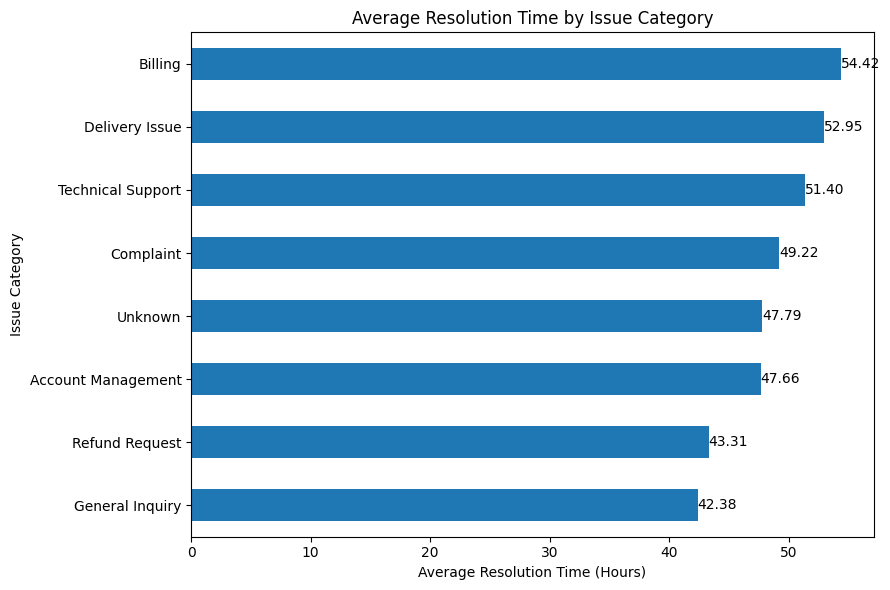

In [66]:
# Average Resolution Time by Issue Category
#to identify whether different types of customer issues have different resolution durations.

plt.figure(figsize=(9, 6))
ax = issue_analysis['avg_resolution_time_hours'].sort_values().plot(kind='barh')
plt.title('Average Resolution Time by Issue Category')
plt.xlabel('Average Resolution Time (Hours)')
plt.ylabel('Issue Category')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Interpretation

The bar chart compares the average resolution time across different issue categories.

- Billing has the highest average resolution time at 54.42 hours.
- Delivery Issue follows with an average of 52.95 hours.
- Technical Support has an average resolution time of 51.40 hours.
- Complaint has an average of 49.22 hours.
- General Inquiry has the lowest average resolution time at 42.38 hours.
- Refund Request has an average resolution time of 43.31 hours.

Overall, the average resolution time varies across issue categories, with Billing showing the highest average and General Inquiry showing the lowest among the categories shown.

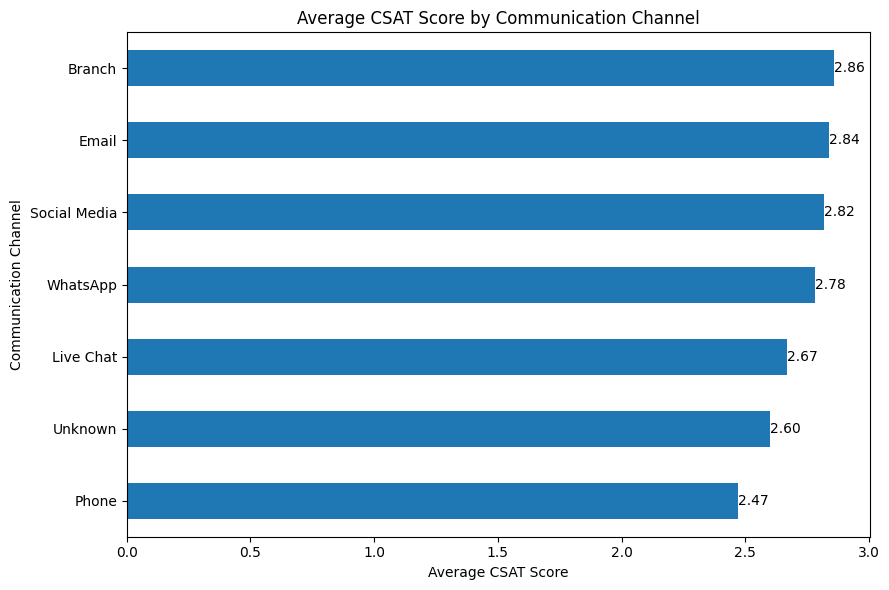

In [67]:
#Average CSAT by Communication Channel
#to understand whether customer satisfaction differs depending on the channel used.

plt.figure(figsize=(9, 6))
ax = channel_analysis['avg_csat_score'].sort_values().plot(kind='barh')
plt.title('Average CSAT Score by Communication Channel')
plt.xlabel('Average CSAT Score')
plt.ylabel('Communication Channel')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Interpretation

The bar chart compares the average CSAT score across different communication channels.

- Branch has the highest average CSAT score at 2.86.
- Email follows with an average CSAT score of 2.84.
- Social Media and WhatsApp have average CSAT scores of 2.82 and 2.78 respectively.
- Live Chat has an average CSAT score of 2.67.
- Phone has the lowest average CSAT score among the known communication channels at 2.47.
- The Unknown category has an average CSAT score of 2.60 and represents records where the original channel information was missing.

Overall, the average CSAT score varies across communication channels, with the observed averages ranging from 2.47 to 2.86 among the known channels.

### Monthly trend analysis

In [68]:
# Monthly Ticket Volume

monthly_ticket_volume = (
    df.groupby('created_month_year')['ticket_id']
      .count()
      .reset_index(name='ticket_count')
)

monthly_ticket_volume

,created_month_year,ticket_count
0,2024-01,63
1,2024-02,48
2,2024-03,66
3,2024-04,72
4,2024-05,66
5,2024-06,56
6,2024-07,59
7,2024-08,54
8,2024-09,52
9,2024-10,66


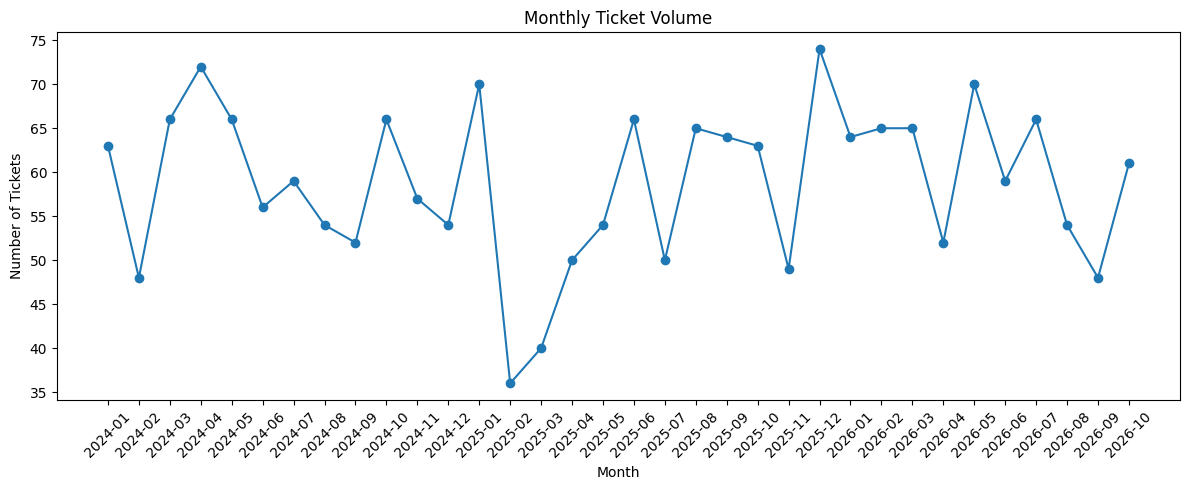

In [69]:
#Monthly Ticket Volume

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_ticket_volume['created_month_year'],
    monthly_ticket_volume['ticket_count'],
    marker='o'
)

plt.title('Monthly Ticket Volume')
plt.xlabel('Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The line chart shows the monthly ticket volume over the available period.

- Ticket volume varies considerably from month to month.
- The highest monthly ticket volume is observed in November 2025, with approximately 74 tickets.
- The lowest monthly ticket volume is observed in January 2025, with approximately 36 tickets.
- Several other months show relatively high ticket volumes, including April 2024, December 2024, December 2025, and May 2026.
- The overall pattern indicates fluctuations in ticket volume rather than a consistent increasing or decreasing trend.

### Multivariate analysis

In [70]:
# Pivot Table: Average CSAT by Issue Category and Priority

csat_pivot = pd.pivot_table(
    df,
    values='csat_score',
    index='issue_category',
    columns='priority',
    aggfunc='mean'
).round(2)

csat_pivot

priority,Critical,High,Low,Medium
issue_category,,,,
Account Management,2.85,2.33,2.77,2.62
Billing,3.14,2.74,3.05,2.93
Complaint,2.17,2.41,3.05,2.60
Delivery Issue,3.83,2.67,2.89,2.28
General Inquiry,3.37,2.76,2.59,2.47
Refund Request,2.36,3.23,2.57,2.26
Technical Support,2.18,3.04,2.42,2.70
Unknown,0.50,3.14,2.50,2.73


### Pivot Table Interpretation

The pivot table was used to examine the average CSAT score across different combinations of issue category and priority.

The results show that CSAT varies across both issue categories and priority levels. For example, Delivery Issue tickets have an average CSAT of 3.83 for Critical priority, compared with 2.28 for Medium priority. Similarly, Refund Request tickets show an average CSAT of 3.23 for High priority and 2.26 for Medium priority.

These differences indicate that the relationship between priority and customer satisfaction is not consistent across all issue categories. Therefore, customer satisfaction should be analyzed using both issue category and priority rather than considering either variable independently.

The Unknown issue category contains records where the original issue category was missing, so its CSAT values should be interpreted cautiously.

Overall, the pivot table provides a more detailed multivariate view of customer satisfaction by combining issue category and priority.

In [71]:
# Correlation Analysis

correlation = df[numerical_columns].corr().round(2)
correlation

,first_response_minutes,resolution_time_hours,csat_score,refund_amount_sar,resolution_days,ticket_age_days
first_response_minutes,1.00,0.36,0.01,-0.00,0.50,0.02
resolution_time_hours,0.36,1.00,0.46,0.11,0.99,NaN
csat_score,0.01,0.46,1.00,0.18,0.04,NaN
refund_amount_sar,-0.00,0.11,0.18,1.00,0.01,NaN
resolution_days,0.50,0.99,0.04,0.01,1.00,NaN
ticket_age_days,0.02,NaN,NaN,NaN,NaN,1.00


In [72]:
correlation = df[numerical_columns].corr().round(2)

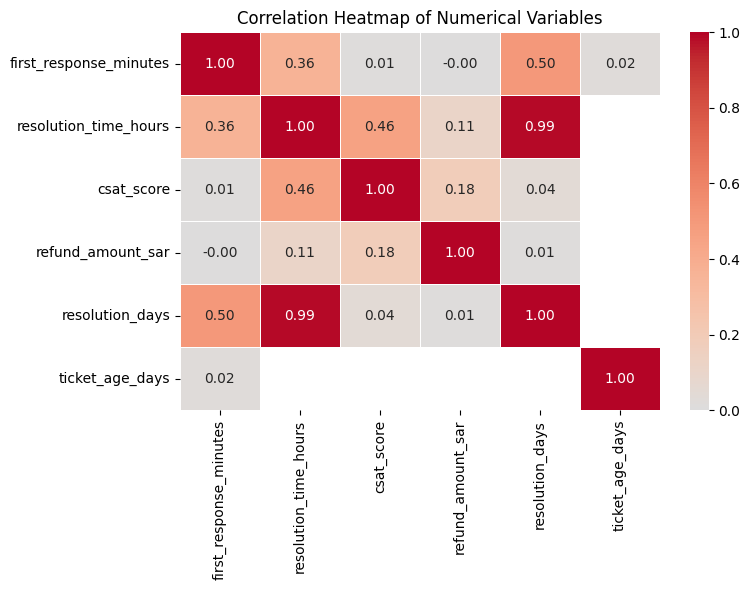

In [73]:
# Correlation Heatmap
#to visually examine the relationships among multiple numerical variables at the same time

import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap shows the linear relationships among the numerical variables.

- `first_response_minutes` and `resolution_time_hours` have a moderate positive correlation of 0.36.
- `first_response_minutes` and `resolution_days` have a moderate positive correlation of 0.50.
- `resolution_time_hours` and `csat_score` have a moderate positive correlation of 0.46.
- `first_response_minutes` and `csat_score` have almost no linear correlation, with a value of 0.01.
- `refund_amount_sar` has weak correlations with the other numerical variables.
- `resolution_time_hours` and `resolution_days` have a very strong correlation of 0.99 because both variables represent resolution duration in different units.
- The correlations involving `ticket_age_days` are mostly unavailable because this feature applies only to unresolved tickets, while several other resolution-related variables apply to resolved tickets.

Overall, the heatmap helps identify the strength and direction of linear relationships among the numerical variables. Correlation indicates association and does not imply causation.

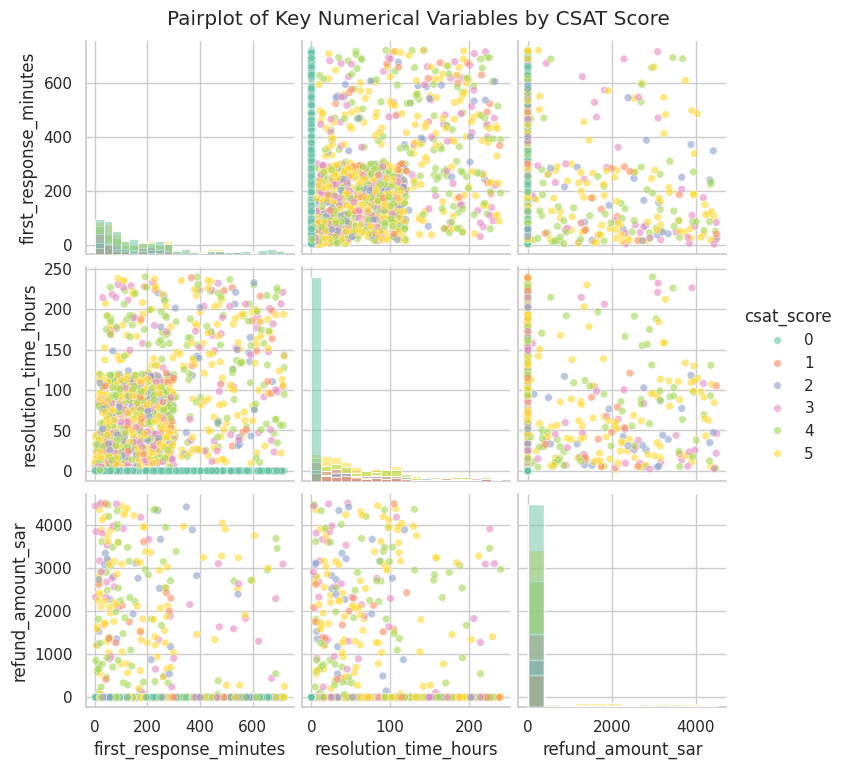

In [74]:
# Multivariate Analysis - Pairplot

pairplot_columns = [
    'first_response_minutes',
    'resolution_time_hours',
    'csat_score',
    'refund_amount_sar'
]

pairplot_data = df[pairplot_columns].dropna()

sns.set_theme(style='whitegrid')

pairplot = sns.pairplot(
    pairplot_data,
    hue='csat_score',
    palette='Set2',
    diag_kind='hist',
    plot_kws={'alpha': 0.6, 's': 30}
)

pairplot.fig.suptitle(
    'Pairplot of Key Numerical Variables by CSAT Score',
    y=1.02
)

plt.show()

### Interpretation

The pairplot shows the relationships among first response time, resolution time, CSAT score, and refund amount simultaneously.

- The plot shows a positive relationship between `first_response_minutes` and `resolution_time_hours`, which is consistent with the correlation analysis.
- The relationship between `first_response_minutes` and `csat_score` appears weak, which is also consistent with the very low correlation value of 0.01.
- `resolution_time_hours` and `csat_score` show a noticeable positive association in the dataset, consistent with their correlation value of 0.46.
- `refund_amount_sar` is highly concentrated around zero, with a smaller number of observations having higher refund amounts.
- Using `csat_score` as the hue allows the distribution of observations to be visually compared across different satisfaction scores.
- The pairplot provides a combined view of multiple numerical variables and helps identify relationships, distributions, and possible patterns that may not be as easy to observe from individual charts.

Overall, the pairplot supports the earlier statistical and correlation analysis while providing a visual multivariate view of the customer service data. The observed relationships represent associations and do not imply causation.


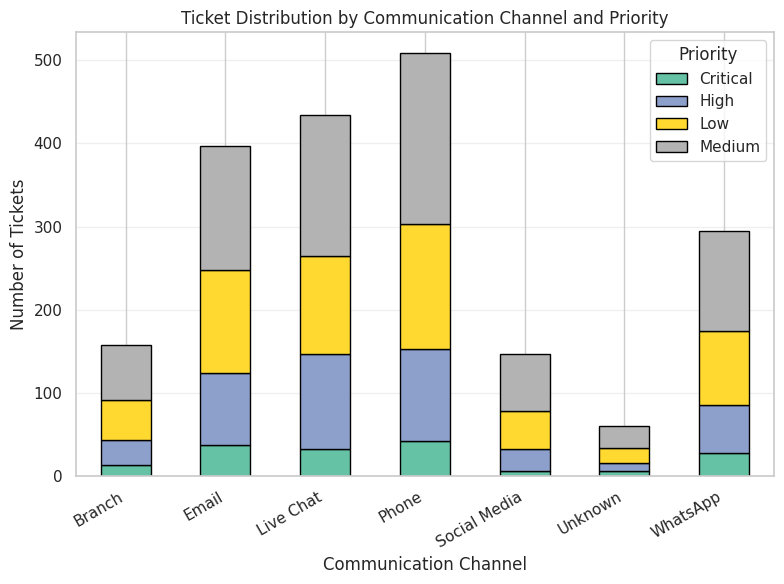

In [75]:
# Multivariate Analysis - Stacked Bar Chart

channel_priority = pd.crosstab(
    df['channel'],
    df['priority']
)

channel_priority.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    colormap='Set2',
    edgecolor='black'
)

plt.title('Ticket Distribution by Communication Channel and Priority')
plt.xlabel('Communication Channel')
plt.ylabel('Number of Tickets')

plt.xticks(rotation=30, ha='right')
plt.legend(title='Priority')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation – Ticket Distribution by Communication Channel and Priority

The stacked bar chart illustrates the distribution of customer service tickets across different communication channels, categorized by ticket priority.

Each bar represents a communication channel, while the colored segments indicate the number of tickets belonging to each priority level.

This visualization helps compare the total ticket volume and priority composition across channels. It can help identify channels with a higher volume of critical or high-priority tickets and support decisions regarding resource allocation and customer service workload management.

**Business Relevance:** Understanding ticket distribution by channel and priority can help customer service teams plan staffing, prioritize workload, and allocate support resources more effectively.

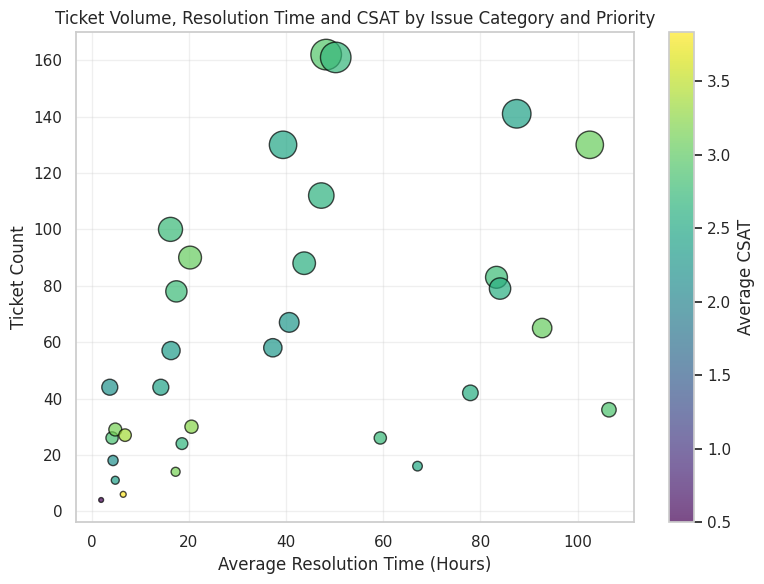

In [76]:
# Group data by Issue Category and Priority
bubble_data = df.groupby(
    ['issue_category', 'priority']
).agg(
    ticket_count=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    avg_csat=('csat_score', 'mean')
).reset_index()

# Create bubble chart
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    bubble_data['avg_resolution_hours'],
    bubble_data['ticket_count'],
    s=bubble_data['ticket_count'] * 3,
    c=bubble_data['avg_csat'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='black'
)

plt.colorbar(scatter, label='Average CSAT')

plt.xlabel('Average Resolution Time (Hours)')
plt.ylabel('Ticket Count')

plt.title(
    'Ticket Volume, Resolution Time and CSAT by Issue Category and Priority'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation – Ticket Volume, Resolution Time and Customer Satisfaction

The bubble chart illustrates the relationship between ticket volume, average resolution time, and customer satisfaction across different issue categories and priority levels.

The X-axis represents average resolution time, while the Y-axis represents the number of tickets. Bubble size indicates ticket volume, and bubble color represents average customer satisfaction.

This visualization helps identify issue-priority combinations that have a high ticket volume, longer resolution times, or relatively lower customer satisfaction.

It provides a combined view of operational workload and customer experience, helping the customer service team identify areas that may require further investigation and process improvement.

**Business Relevance:** This analysis can support workload management, prioritization of service improvements, and monitoring of customer satisfaction across different ticket categories.

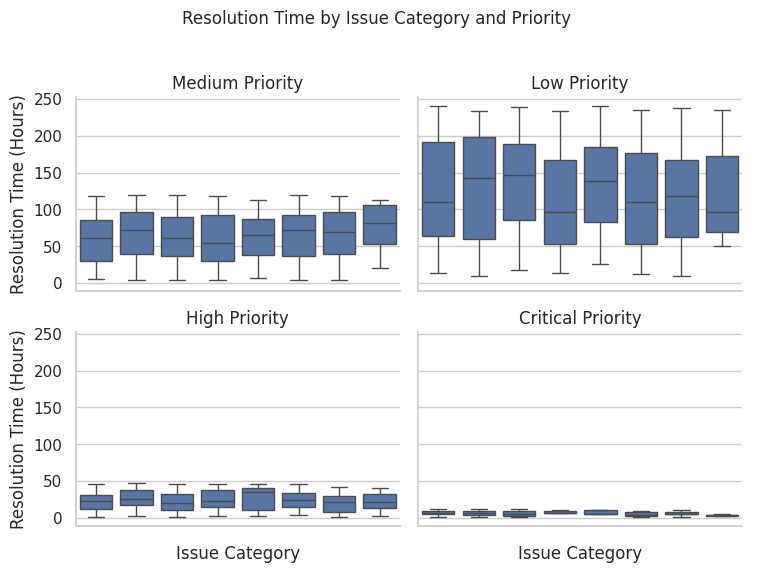

In [77]:
# Select resolved tickets only
resolved_data = df[
    (df['resolution_status'] == 'Resolved') &
    (df['resolution_time_hours'].notna())
].copy()
# Create faceted box plot
g = sns.catplot(
    data=resolved_data,
    x='issue_category',
    y='resolution_time_hours',
    col='priority',
    col_wrap=2,
    kind='box',
    height=2.8,
    aspect=1.35,
    showfliers=False
)

g.set_axis_labels('Issue Category', 'Resolution Time (Hours)')
g.set_titles('{col_name} Priority')
g.set_xticklabels(rotation=45, ha='right', fontsize=7)

g.fig.suptitle(
    'Resolution Time by Issue Category and Priority',
    fontsize=12,
    y=1.02
)

g.fig.tight_layout()
plt.show()

### Interpretation – Resolution Time Distribution by Issue Category and Priority

The faceted box plot compares the distribution of ticket resolution time across different issue categories and priority levels, considering only resolved tickets.

Each panel represents a priority level, while the X-axis shows issue categories and the Y-axis represents resolution time in hours.

The median line indicates the typical resolution time, while the box represents the middle 50% of observations. Whiskers and individual points help identify the spread of resolution times and potential outliers.

This analysis helps identify variations in resolution efficiency across issue categories and priorities. It also highlights categories with greater variability or unusually long resolution times.

**Business Relevance:** The findings can help customer service teams investigate delays, review workload distribution, and identify opportunities to improve ticket resolution processes.

In [78]:
#Export cleaned dataset
df.to_csv('Customer_Service_Cleaned_Final.csv', index=False)
print("Fresh CSV created successfully")

Fresh CSV created successfully


In [79]:
#Download the dataset
from google.colab import files
files.download('Customer_Service_Cleaned_Final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Key Insights

### 1. Priority-based Response Performance
Critical tickets receive a much faster first response of 14.82 minutes, while Low-priority tickets take 373.60 minutes, showing a substantial difference in response performance across priority levels.
### 2. Major Workload Areas
Technical Support (436 tickets) and Billing (421 tickets) are the two largest issue categories, making them important areas for workload management and service improvement.
### 3. Resolution Efficiency
Billing has the highest average resolution time at 54.42 hours, indicating that billing-related cases may require more time or involve more complex resolution processes.
### 4. Channel-level Customer Satisfaction
Average CSAT varies across communication channels, with Branch recording the highest average of 2.86 and Phone the lowest at 2.47 among the known channels.
### 5. Response Time vs Customer Satisfaction
The correlation between first response time and CSAT is only 0.01, suggesting that faster initial responses alone do not show a meaningful linear relationship with customer satisfaction in this dataset.

# Business Recommendations

### 1. Implement Priority-Based Response SLAs
Critical and High-priority tickets receive much faster responses compared with Low-priority tickets. The organization should establish clear response-time targets for each priority level to ensure consistent and timely customer support.

### 2. Allocate More Resources to Technical Support and Billing
Technical Support and Billing are the two highest-volume issue categories. Additional agents and resources should be allocated to these areas to manage workload effectively and improve resolution efficiency.

### 3. Improve Billing Resolution Efficiency
Billing has the highest average resolution time at approximately **54.42 hours**. The organization should identify the major causes of billing-related delays and streamline the billing and refund resolution processes.

### 4. Improve the Phone Support Experience
Phone support has the lowest average CSAT among the major service channels, at approximately **2.47**. The organization should review call handling, waiting times, agent performance, and escalation procedures to identify opportunities for improvement.

### 5. Focus on Resolution Quality, Not Only Response Speed
The correlation between first response time and CSAT is approximately **0.01**, indicating almost no linear relationship. Therefore, improving customer service should focus not only on faster initial responses but also on providing effective and timely issue resolution.



## Future Enhancements

### 1. Incorporate more recent and larger customer service data  
   Use a larger and more recent dataset to identify long-term trends and improve the reliability of insights.

### 2. Automate data refresh and dashboard updates  
   Automate the data preparation and reporting process to enable more efficient monitoring of ticket performance and customer satisfaction.

### 3. Enhance customer experience analysis  
   Incorporate additional factors such as resolution quality, response time, communication channel, priority, and issue category for deeper analysis.

### 4. Extend the analysis with predictive analytics  
   Future analysis can explore predicting tickets that are likely to remain unresolved or receive lower customer satisfaction.

### 5. Implement advanced Power BI features  
   Enhance the dashboard using drill-through, report tooltips, dynamic KPIs, and What-If analysis to support deeper and more interactive decision-making.

# Conclusion

Overall, the analysis shows that customer service performance varies across priorities, issue categories, channels, and locations. Technical Support and Billing contribute significantly to the workload, while resolution efficiency and customer satisfaction differ across service areas. The findings highlight the need for better resource allocation, faster resolution, and improved customer experience.